# Adaptive decomposition: three-condition comparison

This notebook compares three decomposition conditions on the same simulated dataset
(index flexion at 15% MVC, wrist angle 0 → −40° staircase pattern).
The first 30 s is the calibration segment; adaptation runs over all 190 s.

Compares results of no adaptation with adaptation using manually selected hyperparameters.

**Loss definitions**
- **wh_loss**: KL divergence between online and calibration whitened covariance (median over batches)
- **sv_loss**: squared contrast error (log-cosh kurtosis vs. calibration) per source
- **centroid_loss**: squared centroid deviation from calibration (spike + base) per source

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, run_with_optimization
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

## 1. Load data

In [2]:
path_emg    = Path('..', 'data', 'example', 'data_sim.hdf5')
path_decomp = Path('..', 'data', 'example', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)
print(data.keys())

n_units = data['sep_vectors'].shape[0]
print(f'Units: {n_units},  samples: {data["emg"].shape[0]},  fs: {data["fs"]} Hz')

dict_keys(['emg', 'timestamps', 'fs', 'force_profile', 'angle_profile', 'ch_map', 'whitening', 'sep_vectors', 'base_centr', 'spikes_centr', 'ext_fact', 'emg_calib', 'ipts_calib', 'spikes_calib', 'spikes_gt', 'preprocess'])
Units: 18,  samples: 389120,  fs: 2048 Hz


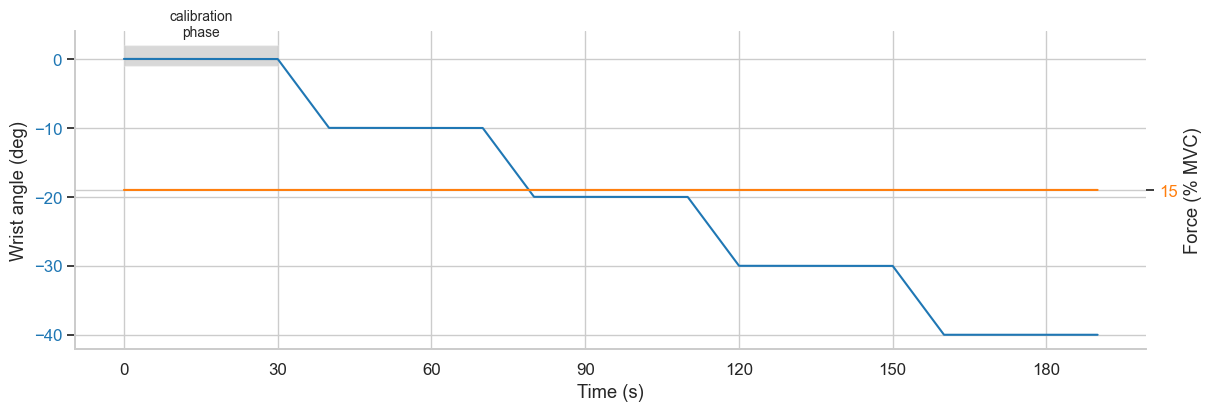

In [3]:
fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
ax.add_patch(Rectangle((0, -1), 30, 3, facecolor='grey', alpha=0.3))
ax.text(15, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10))
ax.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
ax.set(ylabel='Wrist angle (deg)', xlabel='Time (s)')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax1 = ax.twinx()
ax1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
ax1.set(ylabel='Force (% MVC)', yticks=[15])
ax1.tick_params(axis='y', labelcolor='tab:orange')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax1.spines[spine].set_visible(False)
ax1.set(xticks=range(0, 191, 30))
plt.show()

## 2. No adaptation

All adaptation flags disabled; the calibration whitening matrix and separation vectors are applied unchanged to the full recording.

In [48]:
cfg_no = Config()
cfg_no.ext_fact          = data['ext_fact']
cfg_no.adapt_wh          = False
cfg_no.adapt_sv          = False
cfg_no.adapt_sd          = False
cfg_no.compute_loss      = True
cfg_no.log_centroid_loss = True
cfg_no.device            = 'cpu'
cfg_no.wh_mode           = 'kl_to_cal'
cfg_no.contrast_scope    = 'batch_based'

dec_no = AdaptDecomp(
    emg          = data['emg'].clone(),
    whitening    = data['whitening'].clone(),
    sep_vectors  = data['sep_vectors'].clone(),
    base_centr   = data['base_centr'].clone(),
    spikes_centr = data['spikes_centr'].clone(),
    emg_calib    = data['emg_calib'].clone(),
    ipts_calib   = data['ipts_calib'].clone(),
    spikes_calib = data['spikes_calib'].clone(),
    preprocess   = data['preprocess'],
    config       = cfg_no,
)
out_no = dec_no.run()
print('No-adaptation run complete.')

No-adaptation run complete.


## 3. Adaptation

In [ ]:
cfg_adapt = Config()

# Basic settings
cfg_adapt.device            = 'cpu'
cfg_adapt.ext_fact          = data['ext_fact']

# Adaptation on
cfg_adapt.adapt_wh          = True
cfg_adapt.adapt_sv          = True
cfg_adapt.adapt_sd          = True

# Logging settings
cfg_adapt.compute_loss      = True
cfg_adapt.trace_check       = True
cfg_adapt.log_wh_trace      = True
cfg_adapt.log_centroid_loss = True

# Hyperparameters
cfg_adapt.wh_mode           = 'kl_to_cal'
cfg_adapt.contrast_scope    = 'spike_based'
cfg_adapt.eta_b             = 1
cfg_adapt.eta_v             = 1
cfg_adapt.max_rel_delta_v   = 8.4e-3
cfg_adapt.max_rel_delta_b   = 4.5e-2
cfg_adapt.max_iter_b        = 5

dec_adapt = AdaptDecomp(
    emg          = data['emg'].clone(),
    whitening    = data['whitening'].clone(),
    sep_vectors  = data['sep_vectors'].clone(),
    base_centr   = data['base_centr'].clone(),
    spikes_centr = data['spikes_centr'].clone(),
    emg_calib    = data['emg_calib'].clone(),
    ipts_calib   = data['ipts_calib'].clone(),
    spikes_calib = data['spikes_calib'].clone(),
    preprocess   = data['preprocess'],
    config       = cfg_adapt,
)
out_adapt = dec_adapt.run()
print('Adaptation run complete.')


Adaptation run complete.


## 5. Execution time per batch

In [70]:
cond_labels  = ['No adaptation', 'Adaptation']
cond_colors  = {
    'No adaptation':    'tab:orange',
    'Adaptation':       'tab:blue',
}
cond_outputs = {
    'No adaptation':    out_no,
    'Adaptation':       out_adapt,
}

for label in cond_labels:
    out = cond_outputs[label]
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()

No adaptation
-------------
       wh_time_ms: 9.901 ± 1.709 ms
       sv_time_ms: 0.075 ± 0.028 ms
       sd_time_ms: 0.559 ± 0.253 ms
    total_time_ms: 10.535 ± 1.767 ms

Adaptation
----------
       wh_time_ms: 11.098 ± 1.431 ms
       sv_time_ms: 7.306 ± 0.592 ms
       sd_time_ms: 0.484 ± 0.212 ms
    total_time_ms: 18.889 ± 1.575 ms



## 6. Loss trajectories

- **wh_loss**: scalar KL error² (median over batches)
- **sv_loss**: squared contrast error per source (log-cosh kurtosis deviation from calibration)
- **centroid_loss**: squared centroid deviation per source (√ = RMS shift in detection-domain units)

A value near zero means the online statistics match calibration.

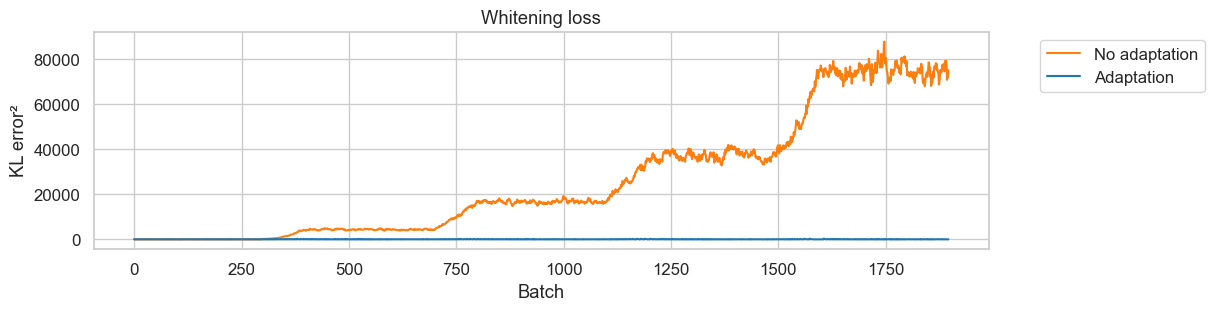

In [71]:
fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label in cond_labels:
    ax.plot(cond_outputs[label]['wh_loss'][10:-1], label=label, color=cond_colors[label])
ax.set(xlabel='Batch', ylabel='KL error²', title='Whitening loss')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

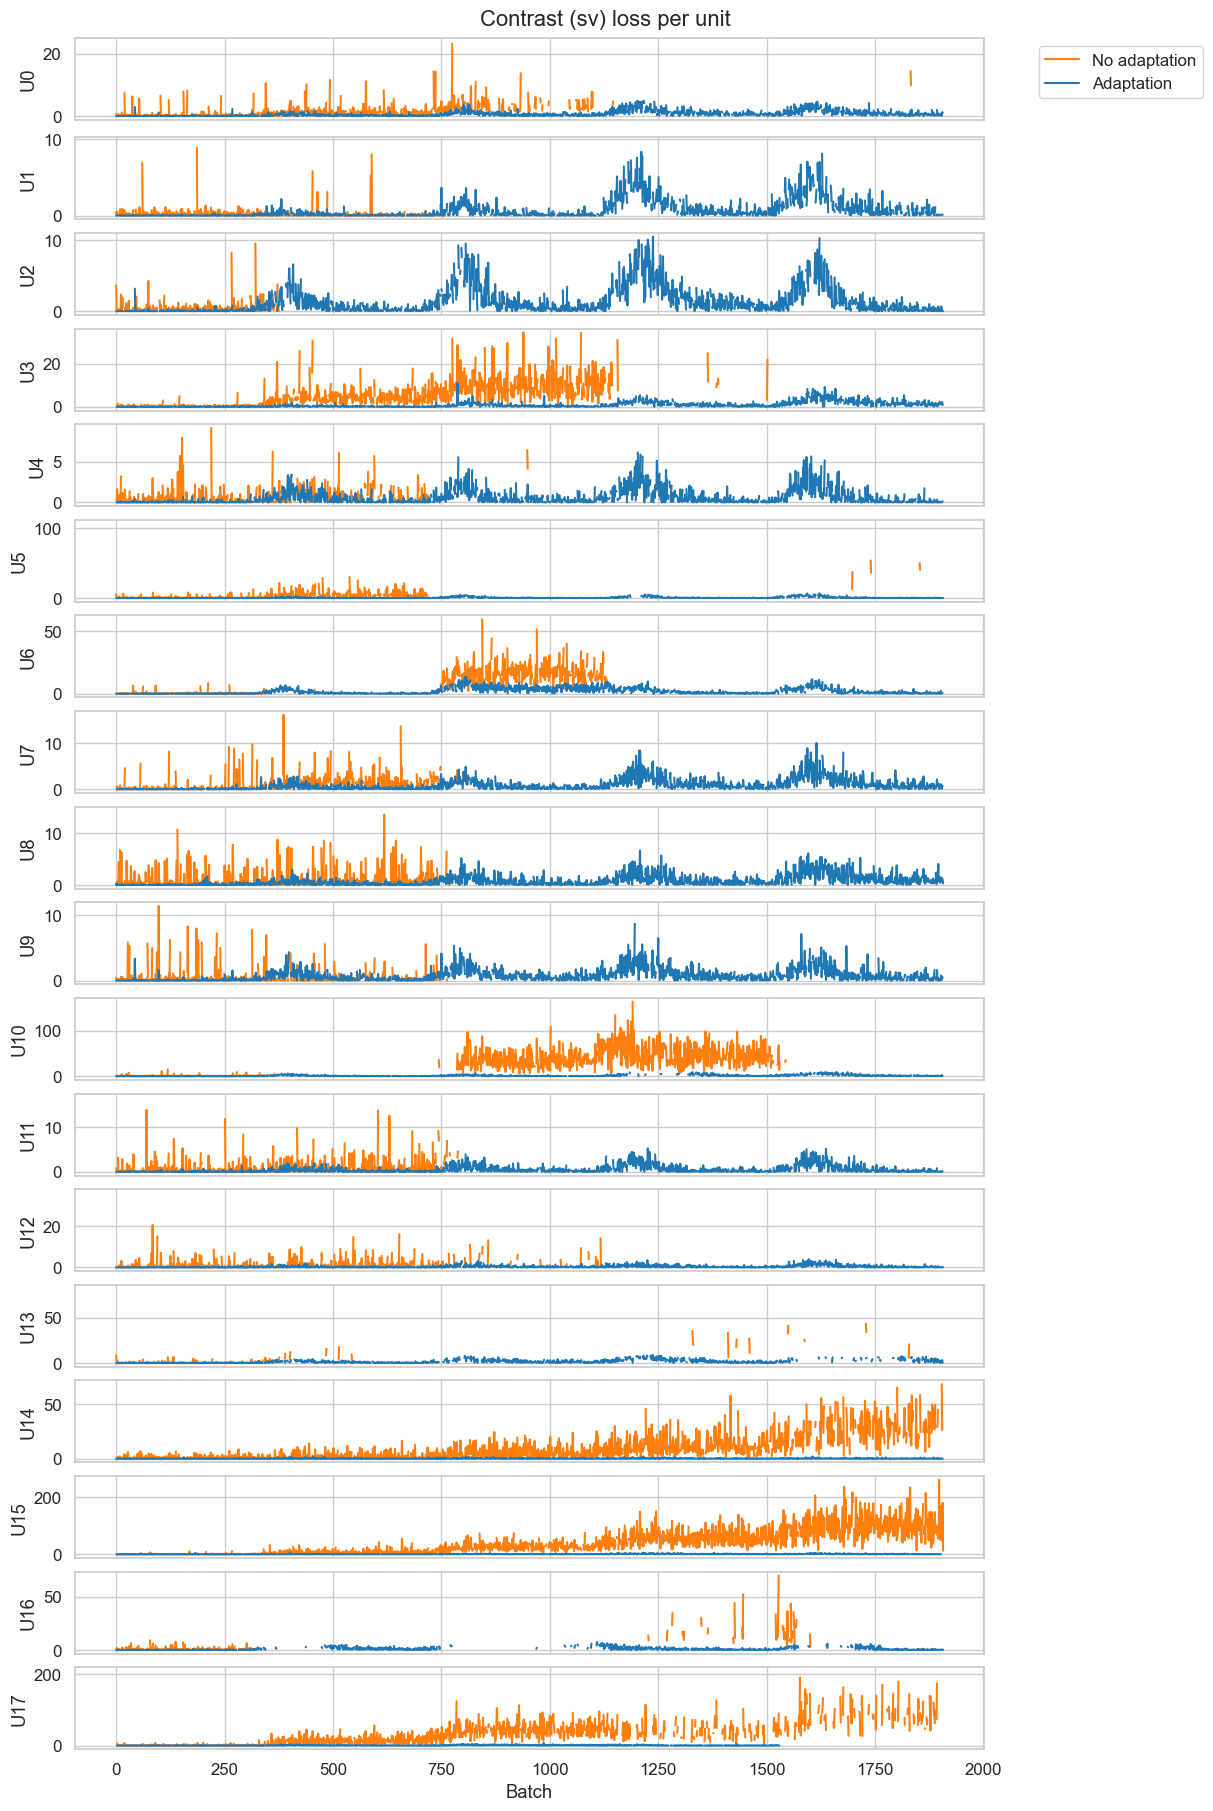

In [72]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        axs[u].plot(cond_outputs[label]['sv_loss'][:, u], label=label, color=cond_colors[label])
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast (sv) loss per unit')
plt.show()

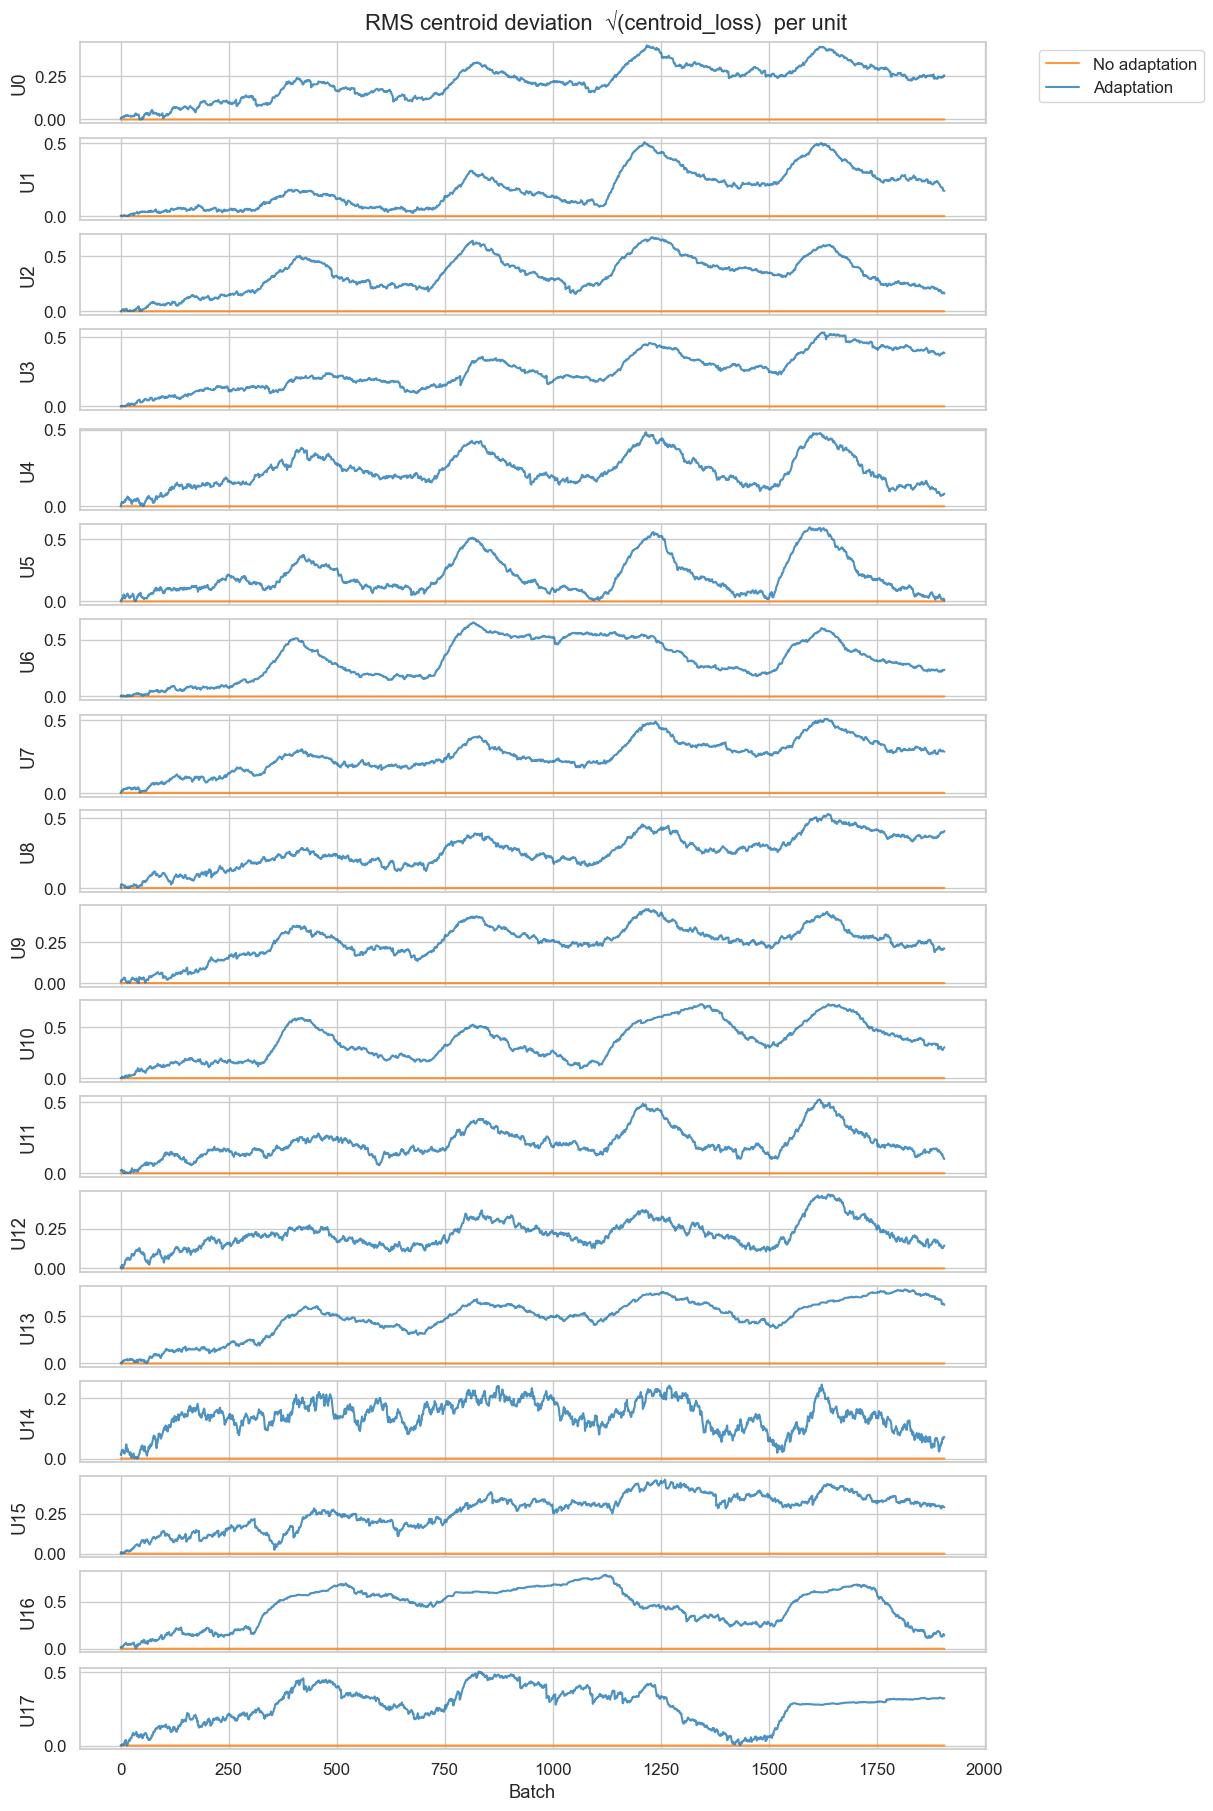

In [73]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        if 'centroid_loss' in out:
            axs[u].plot(
                np.sqrt(out['centroid_loss'][:, u].numpy()),
                label=label, color=cond_colors[label], alpha=0.8,
            )
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('RMS centroid deviation  √(centroid_loss)  per unit')
plt.show()

## 7. IPTs and spike trains

Full recording (0–190 s). Squared IPTs with detected spike times overlaid.

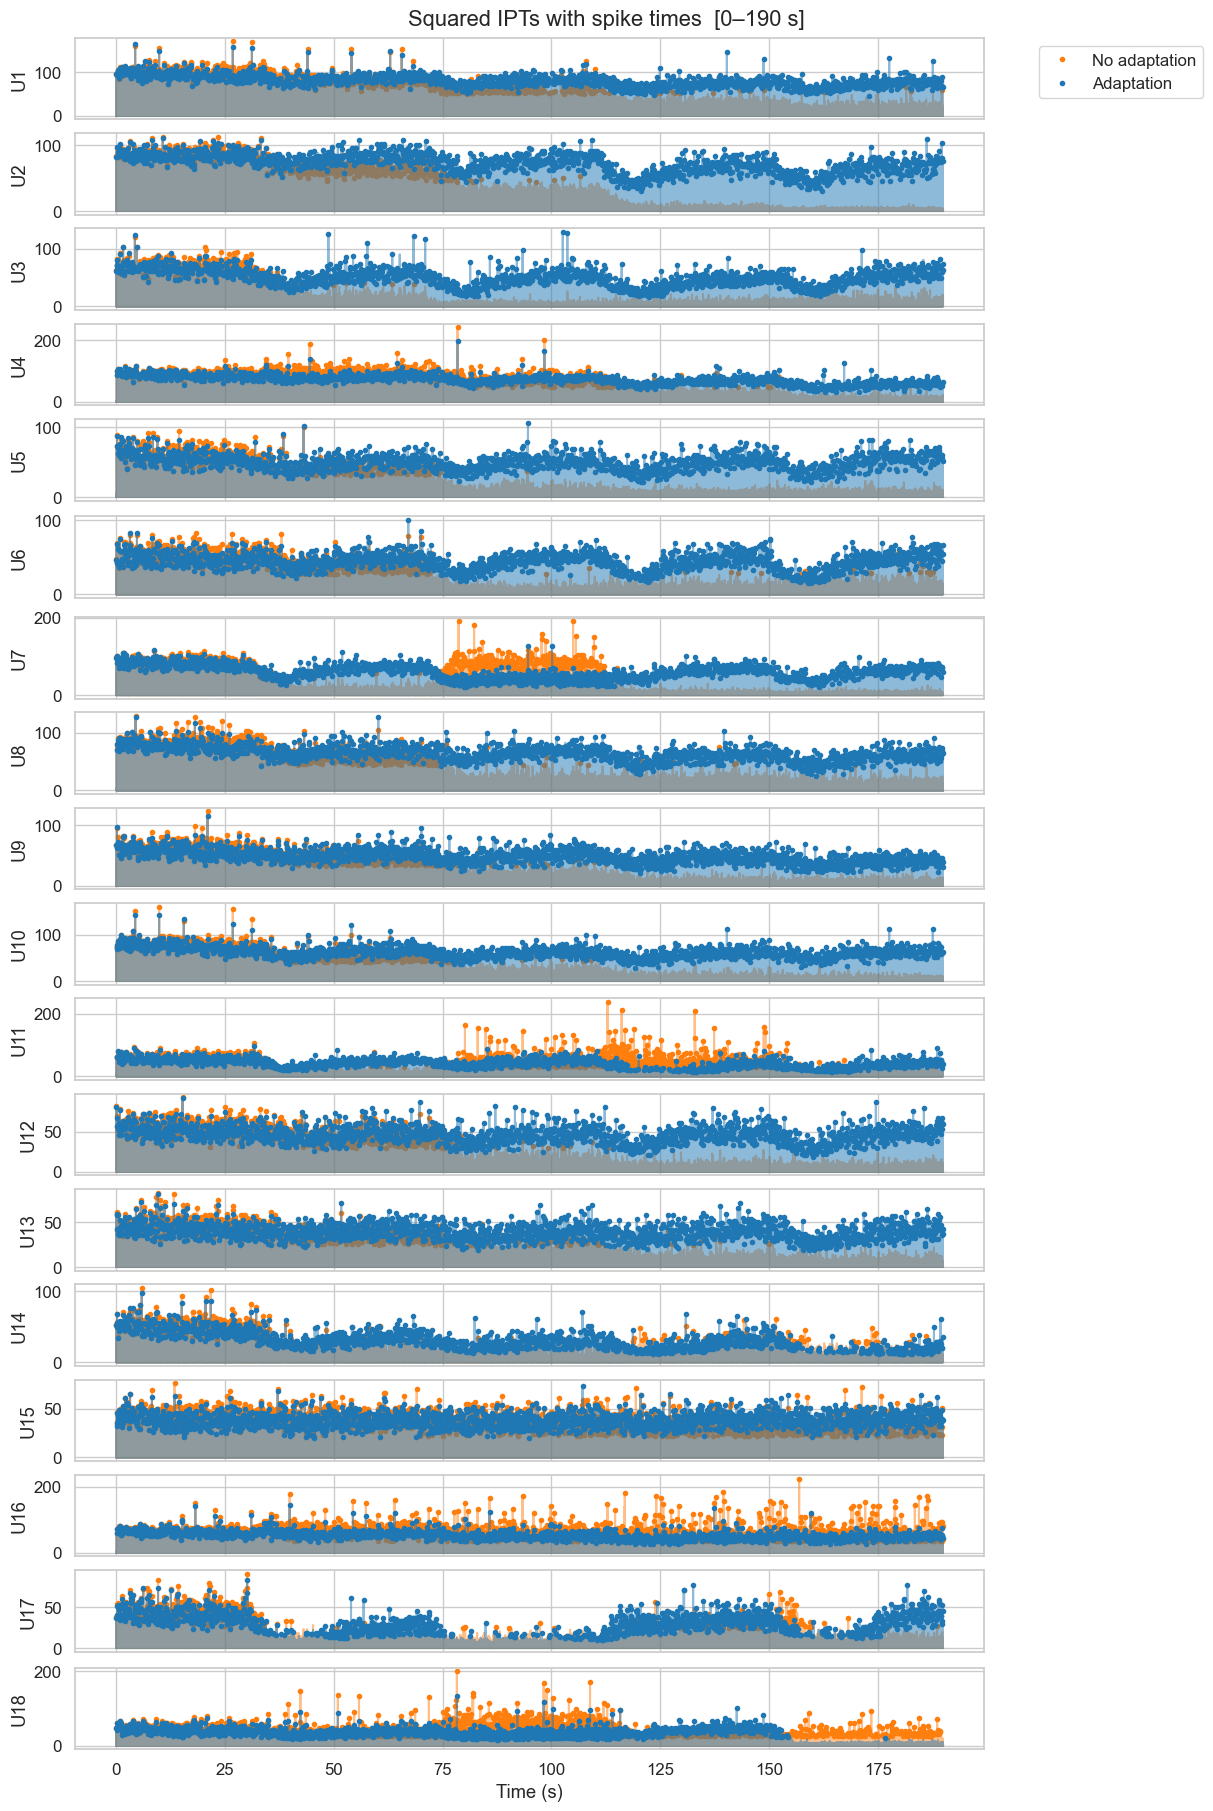

In [74]:
t0, t1 = 0, 190
idxs = np.arange(int(t0 * data['fs']), int(t1 * data['fs']))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)

for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=cond_colors[label], alpha=0.5)
        spike_mask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][spike_mask],
            ipts_sq[spike_mask],
            linestyle='None', marker='.', color=cond_colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'U{u + 1}')

axs[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Squared IPTs with spike times  [{t0}–{t1} s]')
plt.show()

## 8. Decomposition quality metrics

Silhouette measure (SIL), pulse-to-noise ratio (PNR), discharge rate (DR), and coefficient of variation (CoV) compared across all three conditions.  
A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps, CoV ≤ 35%, PNR ≥ 30 dB.

In [75]:
timestamps_np = data['timestamps'].numpy()
ext_fact      = data['ext_fact']

rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps_np, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps_np, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr, dr_low_thr=5, dr_upp_thr=35,
                               cov_thr=0.35, sil_thr=0.9, pnr_thr=30)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
        .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')

                 SIL       PNR (dB)        DR (pps)       CoV (%)      
              median  mean   median   mean   median  mean  median  mean
condition                                                              
Adaptation      0.95  0.93    34.90  35.44     9.09  9.14    0.23  0.64
No adaptation   0.94  0.93    31.78  32.16     5.41  5.91    3.17  3.21

Adaptation: 13 / 18 good units
No adaptation: 0 / 18 good units


/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_28225/3039117822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_28225/3039117822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_28225/3039117822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=

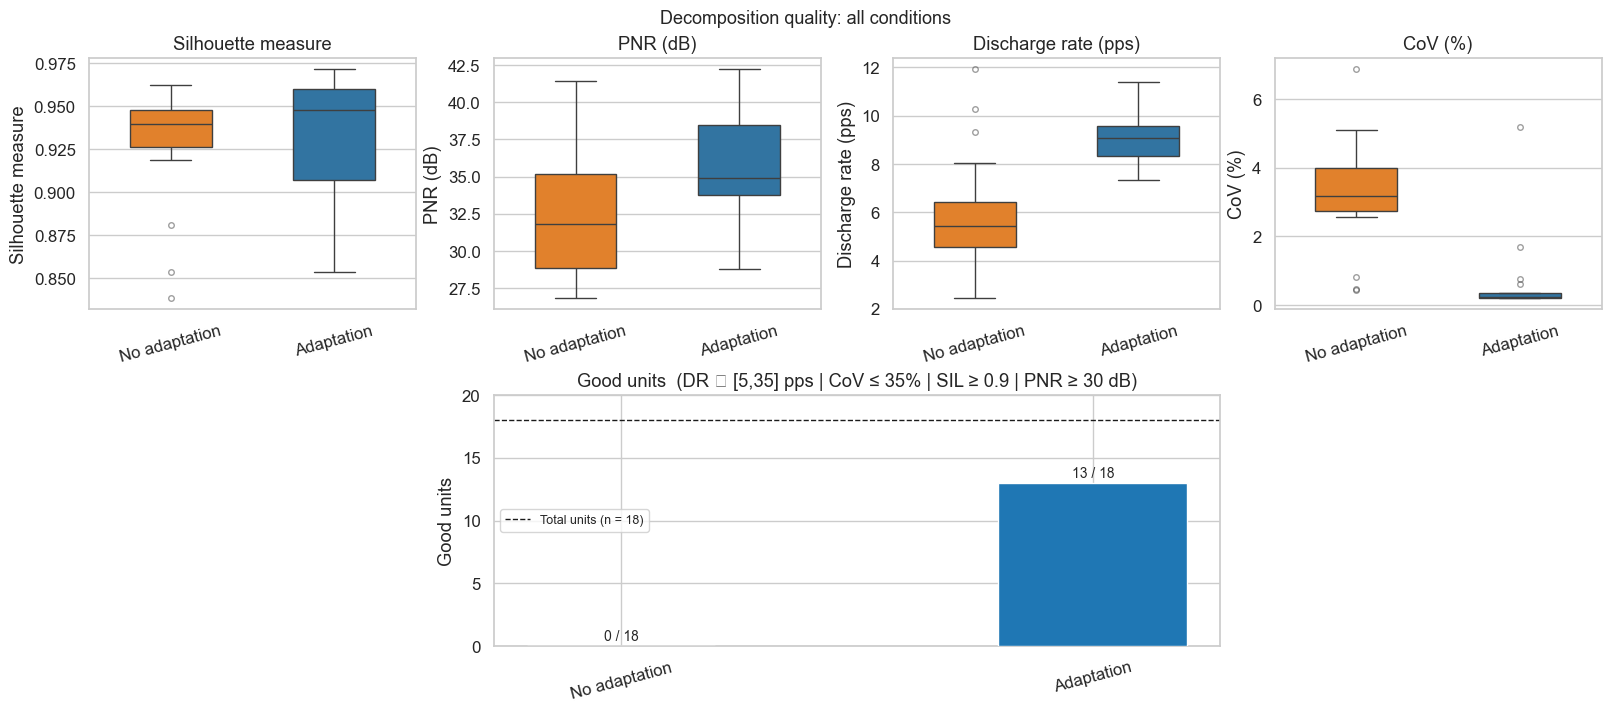

In [76]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(16, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)

ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=15)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] pps | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=15)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Decomposition quality: all conditions', fontsize=13)
plt.show()

## 9. Rate of agreement with ground truth

Unit matching is performed on the calibration segment (first 30 s) using the no-adaptation pairing as the common reference. The bottom subplot shows whether each unit is classified as **good** (●) or **bad** (✗) under each condition, enabling direct correlation between separation quality and agreement with ground truth.

In [77]:
cal_idx = np.arange(0, int(30 * data['fs']))

roa_no_cal,  pair_no,  _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_no['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)
roa_adapt_cal, pair_adapt, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_adapt['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)

print(f'RoA calibration | No adaptation:    {roa_no_cal.mean()*100:.2f} ± {roa_no_cal.std()*100:.2f}%')
print(f'RoA calibration | Adaptation:       {roa_adapt_cal.mean()*100:.2f} ± {roa_adapt_cal.std()*100:.2f}%')

# No-adapt pairing is the common reference across all conditions
pair_arr   = np.array(pair_no)
sim_spikes = data['spikes_gt'].numpy()[:, pair_arr[:, 0]]

RoA calibration | No adaptation:    99.40 ± 0.49%
RoA calibration | Adaptation:       99.34 ± 0.48%


RoA full | No adaptation:   37.88 ± 18.23%  (med: 37.29%)
RoA full | Adaptation:      84.79 ± 25.58%  (med: 98.76%)


/opt/miniconda3/envs/decomposition/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


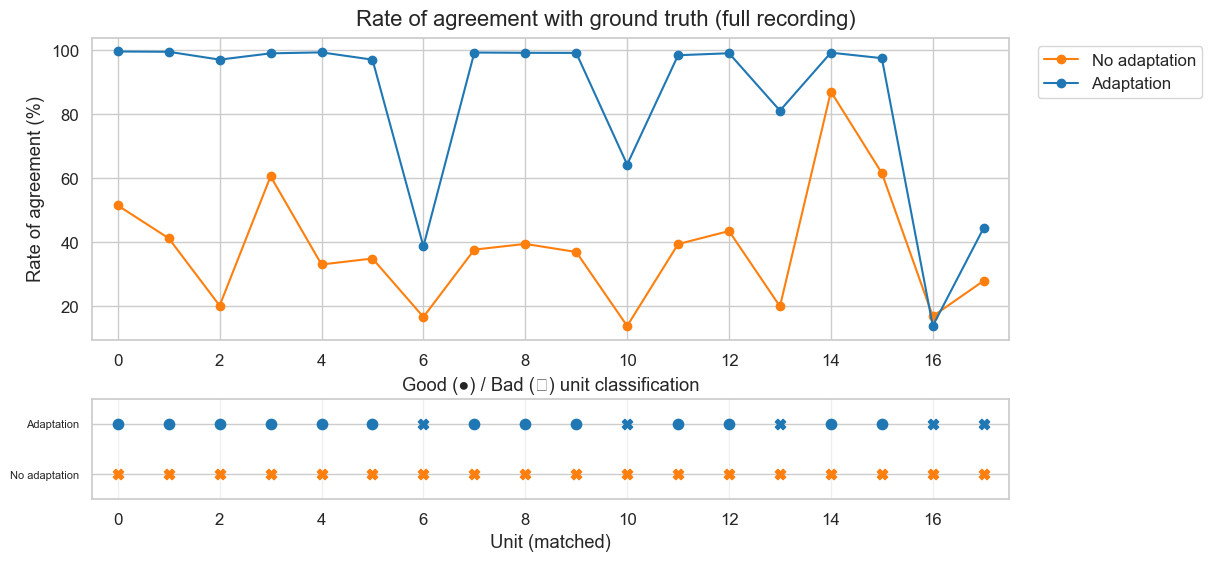

In [78]:
roa_no_full,  _, _ = rate_of_agreement_paired(sim_spikes, out_no['spikes'].numpy(),  fs=data['fs'], tol_spike_ms=2)
roa_adapt_full, _, _ = rate_of_agreement_paired(sim_spikes, out_adapt['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)

unit_ids = pair_arr[:, 1]
n_pairs  = len(unit_ids)
x        = np.arange(n_pairs)

print(f'RoA full | No adaptation:   {roa_no_full.mean()*100:.2f} ± {roa_no_full.std()*100:.2f}%  (med: {np.median(roa_no_full)*100:.2f}%)')
print(f'RoA full | Adaptation:      {roa_adapt_full.mean()*100:.2f} ± {roa_adapt_full.std()*100:.2f}%  (med: {np.median(roa_adapt_full)*100:.2f}%)')

good_lookup = {
    label: df_all[df_all['condition'] == label].set_index('unit')['good']
    for label in cond_labels
}

fig, (ax_roa, ax_good) = plt.subplots(
    2, 1, figsize=(12, 5.5), layout='constrained',
    gridspec_kw={'height_ratios': [3, 1]},
)

ax_roa.plot(x, roa_no_full  * 100, marker='o', label='No adaptation',       color=cond_colors['No adaptation'])
ax_roa.plot(x, roa_adapt_full * 100, marker='o', label='Adaptation', color=cond_colors['Adaptation'])
ax_roa.set(ylabel='Rate of agreement (%)', xlim=(-0.5, n_pairs - 0.5))
ax_roa.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

y_pos = {'No adaptation': 0, 'Adaptation': 1}
for label in cond_labels:
    for i, uid in enumerate(unit_ids):
        is_good = bool(good_lookup[label].get(uid, False))
        ax_good.scatter(i, y_pos[label],
                        color=cond_colors[label],
                        marker='o' if is_good else 'X',
                        s=55, zorder=3)

ax_good.set_yticks(list(y_pos.values()))
ax_good.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax_good.set(xlabel='Unit (matched)', xlim=(-0.5, n_pairs - 0.5),
            title='Good (●) / Bad (✗) unit classification',
            ylim=(-0.5, len(y_pos) - 0.5))
ax_good.grid(axis='x', alpha=0.3)

plt.suptitle('Rate of agreement with ground truth (full recording)')
plt.show()